# **OFFICIAL RETRIEVAL PIPELINE**

In [ ]:

#
# INSTALL FIRST:
# !pip install -q sentence-transformers scikit-learn pandas tqdm pillow
#
# EXPECTED FOLDER STRUCTURE:
# /content/drive/MyDrive/Mediaeval project/
# ├── Train Data/
# │   ├── news_articles.csv
# │   └── news_images/
# ├── Test data/
# │   ├── news_articles_evaluation.csv   (optional for analysis)
# │   └── news_articles_test.csv
# └── submission/
#
# OUTPUT:
# /content/drive/MyDrive/Mediaeval project/submission/FAST-MS(DS)/Official_Retrieval/
# ├── test_predictions.csv
# ├── self_retrieval_validation.csv
# ├── train_embeddings.npy
# ├── FAST-MS(DS)_-_Official_Retrieval.zip
# └── FAST-MS(DS)_-_Official_Retrieval/
#     ├── 8501_+_FAST-MS(DS)_+_Official_Retrieval.png
#     └── ...
# ==============================================================

# ========================= INSTALL CHECK =======================
# !pip install -q sentence-transformers scikit-learn pandas tqdm pillow

# ========================= MOUNT DRIVE =========================
from google.colab import drive
import os

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

# ========================= CONFIG ==============================
BASE = "/content/drive/MyDrive/Mediaeval project"

TRAIN_CSV = f"{BASE}/Train Data/news_articles.csv"
TEST_CSV  = f"{BASE}/Test data/news_articles_test.csv"
IMAGE_DIR = f"{BASE}/Train Data/news_images"

GROUP_NAME = "FAST-MS(DS)"
APPROACH_NAME = "Official_Retrieval"

OUTPUT_ROOT = f"{BASE}/submission/{GROUP_NAME}/{APPROACH_NAME}"
SUBMISSION_FOLDER = f"{OUTPUT_ROOT}/{GROUP_NAME}_-_{APPROACH_NAME}"
ZIP_PATH = f"{OUTPUT_ROOT}/{GROUP_NAME}_-_{APPROACH_NAME}.zip"

BATCH_SIZE = 32
TOP_K_RETRIEVAL = 50
TOP_K_FINAL = 5
VALIDATION_SAMPLES = 500   # automatic accuracy check on training data

os.makedirs(OUTPUT_ROOT, exist_ok=True)
os.makedirs(SUBMISSION_FOLDER, exist_ok=True)

# ========================= IMPORTS =============================
import re
import zipfile
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer, CrossEncoder
import torch

print("Using device:", "cuda" if torch.cuda.is_available() else "cpu")

# ========================= HELPERS =============================
def read_csv_robust(path):
    for enc in ["utf-8", "latin1", "cp1252"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except:
            pass
    raise ValueError(f"Could not read CSV: {path}")

def standardize_columns(df):
    df.columns = [str(c).strip() for c in df.columns]

    if "article_title" not in df.columns:
        raise ValueError("Missing article_title column")

    if "article_id" not in df.columns:
        df["article_id"] = np.arange(len(df))

    if "article_url" not in df.columns:
        df["article_url"] = ""

    if "image_id" not in df.columns:
        df["image_id"] = "N/A"

    df["article_title"] = df["article_title"].fillna("").astype(str)
    df["article_url"] = df["article_url"].fillna("").astype(str)
    df["image_id"] = df["image_id"].fillna("N/A").astype(str)

    df = df[df["article_title"].str.strip() != ""].reset_index(drop=True)
    return df

def slug_to_text(url):
    if pd.isna(url):
        return ""

    url = str(url).strip()

    if url.upper() == "N/A" or url == "":
        return ""

    slug = url.split("/")[-1]
    slug = slug.replace("-", " ")
    slug = slug.replace("_", " ")
    slug = re.sub(r"[^A-Za-z0-9 ]", " ", slug)
    slug = re.sub(r"\s+", " ", slug).strip()

    return slug

def build_text(title, url=""):
    """
    Official task representation:
    Use ONLY title and URL slug when available.
    """
    title = str(title).strip()
    url_text = slug_to_text(url)

    parts = [title, title]  # duplicate title to increase weight

    if url_text and url_text.lower() != title.lower():
        parts.append(url_text)

    # remove duplicates while preserving order
    seen = set()
    final_parts = []

    for p in parts:
        p = p.strip()
        if p and p not in seen:
            final_parts.append(p)
            seen.add(p)

    return ". ".join(final_parts)

def find_image(image_id):
    image_id = str(image_id)

    for ext in ["", ".jpg", ".jpeg", ".png"]:
        path = os.path.join(IMAGE_DIR, image_id + ext if ext else image_id)
        if os.path.exists(path):
            return path

    return None

def save_submission_image(src_path, dst_path):
    img = Image.open(src_path).convert("RGB")
    img = img.resize((460, 260), Image.LANCZOS)
    img.save(dst_path, format="PNG")

# ========================= LOAD DATA ===========================
print("\nLoading datasets...")

train_df = standardize_columns(read_csv_robust(TRAIN_CSV))
test_df  = standardize_columns(read_csv_robust(TEST_CSV))

print("Training rows :", len(train_df))
print("Test rows     :", len(test_df))

# ========================= BUILD TEXTS =========================
print("\nBuilding text representations...")

train_texts = [
    build_text(row.article_title, row.article_url)
    for row in tqdm(train_df.itertuples(index=False), total=len(train_df))
]

test_texts = [
    build_text(row.article_title, row.article_url)
    for row in tqdm(test_df.itertuples(index=False), total=len(test_df))
]

# ========================= LOAD MODELS =========================
print("\nLoading embedding model...")
embed_model = SentenceTransformer("BAAI/bge-large-en-v1.5")

print("Loading reranker...")
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

print("Models loaded successfully!")

# ========================= TRAIN EMBEDDINGS ====================
EMBED_PATH = f"{OUTPUT_ROOT}/train_embeddings.npy"

if os.path.exists(EMBED_PATH):
    print("\nLoading cached embeddings...")
    train_embeddings = np.load(EMBED_PATH)
else:
    print("\nEncoding training articles...")
    train_embeddings = embed_model.encode(
        train_texts,
        batch_size=BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    np.save(EMBED_PATH, train_embeddings)

print("Training embeddings shape:", train_embeddings.shape)

# ========================= VALIDATION ACCURACY =================
print("\n" + "=" * 70)
print("SELF-RETRIEVAL VALIDATION")
print("=" * 70)

validation_df = train_df.sample(
    n=min(VALIDATION_SAMPLES, len(train_df)),
    random_state=42
).reset_index(drop=True)

validation_texts = [
    build_text(row.article_title, row.article_url)
    for row in validation_df.itertuples(index=False)
]

validation_embeddings = embed_model.encode(
    validation_texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

sim_val = cosine_similarity(validation_embeddings, train_embeddings)

top1_correct = 0
top5_correct = 0
validation_rows = []

for i in tqdm(range(len(validation_df))):
    query_text = validation_texts[i]
    true_image = str(validation_df.iloc[i]["image_id"])

    candidate_indices = np.argsort(sim_val[i])[::-1][:TOP_K_RETRIEVAL]

    pairs = [(query_text, train_texts[j]) for j in candidate_indices]
    rerank_scores = reranker.predict(pairs)

    reranked = np.argsort(rerank_scores)[::-1]
    final_indices = [candidate_indices[j] for j in reranked[:5]]

    predicted_top1 = str(train_df.iloc[final_indices[0]]["image_id"])
    top5_images = [str(train_df.iloc[j]["image_id"]) for j in final_indices]

    correct_top1 = predicted_top1 == true_image
    correct_top5 = true_image in top5_images

    if correct_top1:
        top1_correct += 1
    if correct_top5:
        top5_correct += 1

    validation_rows.append({
        "query_title": validation_df.iloc[i]["article_title"],
        "true_image": true_image,
        "predicted_top1": predicted_top1,
        "correct_top1": correct_top1,
        "correct_top5": correct_top5
    })

validation_results = pd.DataFrame(validation_rows)
validation_results.to_csv(
    f"{OUTPUT_ROOT}/self_retrieval_validation.csv",
    index=False
)

n = len(validation_df)
print(f"Top-1 Accuracy: {top1_correct / n:.4f} ({top1_correct}/{n})")
print(f"Top-5 Accuracy: {top5_correct / n:.4f} ({top5_correct}/{n})")

# ========================= TEST RETRIEVAL ======================
print("\n" + "=" * 70)
print("RUNNING TEST RETRIEVAL")
print("=" * 70)

test_embeddings = embed_model.encode(
    test_texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

similarity = cosine_similarity(test_embeddings, train_embeddings)

prediction_rows = []

for i in tqdm(range(len(test_df))):
    query_text = test_texts[i]

    candidate_indices = np.argsort(similarity[i])[::-1][:TOP_K_RETRIEVAL]

    pairs = [(query_text, train_texts[j]) for j in candidate_indices]
    rerank_scores = reranker.predict(pairs)

    reranked = np.argsort(rerank_scores)[::-1]
    final_indices = [candidate_indices[j] for j in reranked[:TOP_K_FINAL]]

    best_idx = final_indices[0]

    predicted_image_id = str(train_df.iloc[best_idx]["image_id"])
    matched_title = str(train_df.iloc[best_idx]["article_title"])

    prediction_rows.append({
        "article_id": test_df.iloc[i]["article_id"],
        "query_title": test_df.iloc[i]["article_title"],
        "predicted_image_id": predicted_image_id,
        "matched_title_top1": matched_title,
        "top5_images": " | ".join(
            [str(train_df.iloc[j]["image_id"]) for j in final_indices]
        )
    })

test_predictions = pd.DataFrame(prediction_rows)
PREDICTIONS_CSV = f"{OUTPUT_ROOT}/test_predictions.csv"
test_predictions.to_csv(PREDICTIONS_CSV, index=False)

print("\nSaved predictions:")
print(PREDICTIONS_CSV)

# ========================= CREATE SUBMISSION IMAGES ============
print("\nCreating submission images...")

created = 0
missing = 0

for _, row in tqdm(test_predictions.iterrows(), total=len(test_predictions)):
    article_id = str(row["article_id"])
    predicted_image_id = str(row["predicted_image_id"])

    src_path = find_image(predicted_image_id)

    if src_path is None:
        missing += 1
        continue

    filename = (
        f"{article_id}_+_{GROUP_NAME}_+_{APPROACH_NAME}.png"
    )

    dst_path = os.path.join(SUBMISSION_FOLDER, filename)

    save_submission_image(src_path, dst_path)
    created += 1

print("Images created:", created)
print("Images missing:", missing)

# ========================= CREATE ZIP ==========================
print("\nCreating ZIP file...")

if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for file in os.listdir(SUBMISSION_FOLDER):
        full_path = os.path.join(SUBMISSION_FOLDER, file)
        arcname = os.path.join(
            f"{GROUP_NAME}_-_{APPROACH_NAME}",
            file
        )
        zf.write(full_path, arcname)

# ========================= FINAL SUMMARY =======================
print("\n" + "=" * 70)
print("MEDIAEVAL OFFICIAL SUBMISSION COMPLETED")
print("=" * 70)
print("Validation accuracy file:")
print(f"{OUTPUT_ROOT}/self_retrieval_validation.csv")
print("\nTest predictions:")
print(PREDICTIONS_CSV)
print("\nSubmission folder:")
print(SUBMISSION_FOLDER)
print("\nZIP file ready for submission:")
print(ZIP_PATH)
print("=" * 70)

# NewsImages 2026 — Image Generation Pipeline
## Strategy: Generate images with FLUX.1-schnell from article titles

**What this does:**
- Reads article titles from test + evaluation CSVs
- Converts each title into a visual image generation prompt
- Generates a 460x260px PNG image per article using FLUX
- Saves everything in the exact ZIP structure required for submission

**Requirements:**
- Runtime → Change runtime type → **T4 GPU**
- Google Drive mounted with your CSVs

In [ ]:
# CELL 4 — CONFIG
import os

BASE       = '/content/drive/MyDrive/Mediaeval project'
GROUP_NAME = 'FAST-MS(DS)'   # ← CHANGE THIS to your registered group name
RUN_NAME   = 'FLUX_retrieval'  # ← name for this run (must be unique per submission)

CONFIG = {
    'test_csv':    f'{BASE}/Test data/news_articles_test.csv',
    'eval_csv':    f'{BASE}/Test data/news_articles_evaluation.csv',
    'output_dir':  f'{BASE}/outputs',
    'submit_dir':  f'{BASE}/submission',
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)
os.makedirs(CONFIG['submit_dir'], exist_ok=True)

# Verify CSVs exist
for key in ['test_csv', 'eval_csv']:
    exists = os.path.isfile(CONFIG[key])
    print(f'  {"✓" if exists else "✗ NOT FOUND"}  {key}: {CONFIG[key]}')

print(f'\nGroup name : {GROUP_NAME}')
print(f'Run name   : {RUN_NAME}')
print(f'Folder name: {GROUP_NAME}_{RUN_NAME}')

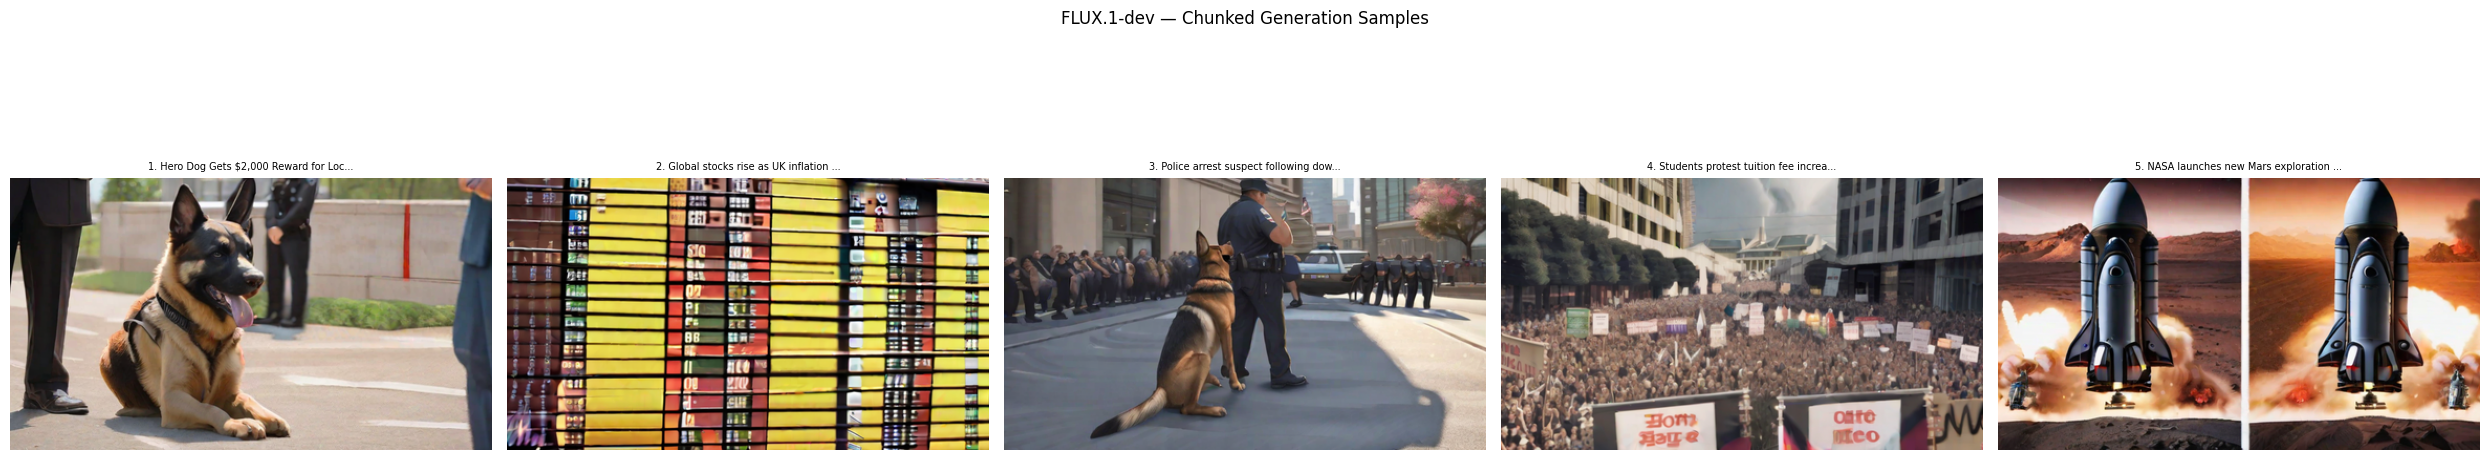

Preview saved successfully!


In [ ]:
# CELL 8B — Load and display generated FLUX images

from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(25, 6))

for i, (title, path) in enumerate(saved_paths):

    img = Image.open(path)

    axes[i].imshow(img)

    axes[i].set_title(
        f'{i+1}. {title[:35]}...',
        fontsize=7
    )

    axes[i].axis('off')

plt.suptitle('FLUX.1-dev — Chunked Generation Samples', fontsize=12)

plt.tight_layout()

plt.savefig(
    f"{CONFIG['output_dir']}/sample_preview_flux_chunked.png",
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Preview saved successfully!")